# Trace CSV Exploration

Loads the scalar transition summaries and the trace CSVs exported by `KoenDataUpdated/export_to_csv_traces.m`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import context_contrasting.data_analysis.transitions_helpers as th

DATA_DIR = Path.cwd()
if DATA_DIR.name != "data_analysis":
    DATA_DIR = Path("context_contrasting/data_analysis")

DATA_DIR

PosixPath('context_contrasting/data_analysis')

In [2]:
summary_paths = {
    "act": DATA_DIR / "transitions_act.csv",
    "post": DATA_DIR / "transitions_post.csv",
}
trace_paths = {
    "act": DATA_DIR / "transitions_act_traces.csv",
    "post": DATA_DIR / "transitions_post_traces.csv",
}

summaries = {name: pd.read_csv(path) for name, path in summary_paths.items()}
traces = {
    name: pd.read_csv(path)
    for name, path in trace_paths.items()
    if path.exists()
}

print("Summary rows:")
for name, frame in summaries.items():
    print(f"  {name}: {len(frame):,} rows")

print("\nTrace rows:")
for name, path in trace_paths.items():
    if name in traces:
        print(f"  {name}: {len(traces[name]):,} rows")
    else:
        print(f"  {name}: missing ({path})")

if set(traces) != set(trace_paths):
    print("\nRun KoenDataUpdated/export_to_csv_traces.m from the KoenDataUpdated folder to create missing trace CSVs.")

Summary rows:
  act: 1,760 rows
  post: 3,984 rows

Trace rows:
  act: 327,360 rows
  post: 494,016 rows


In [3]:
trace_columns = [
    "image_group",
    "image_idx_original",
    "image_idx_within_group",
    "neuron_idx",
    "image_type",
    "stage",
    "time",
    "response",
]
key_columns = trace_columns[:6]

def validate_trace_expansion(name: str) -> pd.DataFrame:
    summary = summaries[name]
    trace = traces[name]
    assert list(trace.columns) == trace_columns

    time_counts = (
        trace.groupby("stage", observed=True)["time"]
        .nunique()
        .rename("n_timepoints")
        .reset_index()
    )
    trace_counts = (
        trace.groupby(key_columns, observed=True)
        .size()
        .rename("trace_rows")
        .reset_index()
    )
    check = (
        summary[key_columns]
        .merge(trace_counts, on=key_columns, how="left", validate="one_to_one")
        .merge(time_counts, on="stage", how="left", validate="many_to_one")
    )
    assert check["trace_rows"].notna().all()
    assert (check["trace_rows"] == check["n_timepoints"]).all()
    return time_counts

if set(traces) == set(trace_paths):
    for name in ("act", "post"):
        print(f"{name} timepoints per summary row:")
        display(validate_trace_expansion(name))

act timepoints per summary row:


,stage,n_timepoints
0,Pre,124
1,Task,248


post timepoints per summary row:


,stage,n_timepoints
0,Post,124
1,Pre,124


In [4]:
act_table = th.load_transition_table(summary_paths["act"])
post_table = th.load_transition_table(summary_paths["post"])

sector_summaries = {
    "act": th.build_mean_summary(
        act_table,
        image_group="all",
        pre_stage="Pre",
        target_stage="Task",
        threshold=0.3,
    ),
    "post_familiar": th.build_mean_summary(
        post_table,
        image_group="familiar",
        pre_stage="Pre",
        target_stage="Post",
        threshold=0.3,
    ),
    "post_novel": th.build_mean_summary(
        post_table,
        image_group="novel",
        pre_stage="Pre",
        target_stage="Post",
        threshold=0.3,
    ),
}

for name, frame in sector_summaries.items():
    print(name)
    display(th.sector_fraction_table(frame))

act


,RotatedSector,Count,Fraction,Mean_dNorm,Median_dNorm,ExpectedFraction,DeltaFromExpected,AboveExpected
0,+NO axis,11,0.100000,0.668454,0.624074,0.25,-0.150000,False
1,+O axis,23,0.209091,1.000584,0.599505,0.25,-0.040909,False
2,-NO axis,32,0.290909,0.713264,0.670614,0.25,0.040909,True
3,-O axis,3,0.027273,0.561628,0.553152,0.25,-0.222727,False
4,small ∆,41,0.372727,0.177407,0.174235,0.25,0.122727,True


post_familiar


,RotatedSector,Count,Fraction,Mean_dNorm,Median_dNorm,ExpectedFraction,DeltaFromExpected,AboveExpected
0,+NO axis,14,0.084337,0.567305,0.519996,0.25,-0.165663,False
1,+O axis,23,0.138554,0.534648,0.449192,0.25,-0.111446,False
2,-NO axis,54,0.325301,0.725107,0.648476,0.25,0.075301,True
3,-O axis,12,0.072289,0.767650,0.682274,0.25,-0.177711,False
4,small ∆,63,0.379518,0.172867,0.173230,0.25,0.129518,True


post_novel


,RotatedSector,Count,Fraction,Mean_dNorm,Median_dNorm,ExpectedFraction,DeltaFromExpected,AboveExpected
0,+NO axis,42,0.253012,0.779351,0.635522,0.25,0.003012,True
1,+O axis,16,0.096386,0.586419,0.495037,0.25,-0.153614,False
2,-NO axis,24,0.144578,0.671524,0.553652,0.25,-0.105422,False
3,-O axis,12,0.072289,0.618965,0.449417,0.25,-0.177711,False
4,small ∆,72,0.433735,0.172471,0.168161,0.25,0.183735,True


In [5]:
def attach_trace_sectors() -> dict[str, pd.DataFrame]:
    if set(traces) != set(trace_paths):
        return {}

    act_lookup = sector_summaries["act"][["neuron_idx", "RotatedSector"]]
    act_traces = traces["act"].merge(act_lookup, on="neuron_idx", how="left", validate="many_to_one")

    post_lookup = pd.concat(
        [
            sector_summaries["post_familiar"][["neuron_idx", "RotatedSector"]].assign(image_group="familiar"),
            sector_summaries["post_novel"][["neuron_idx", "RotatedSector"]].assign(image_group="novel"),
        ],
        ignore_index=True,
    )
    post_traces = traces["post"].merge(
        post_lookup,
        on=["image_group", "neuron_idx"],
        how="left",
        validate="many_to_one",
    )
    return {"act": act_traces, "post": post_traces}

sector_traces = attach_trace_sectors()
sector_traces.keys()

dict_keys(['act', 'post'])

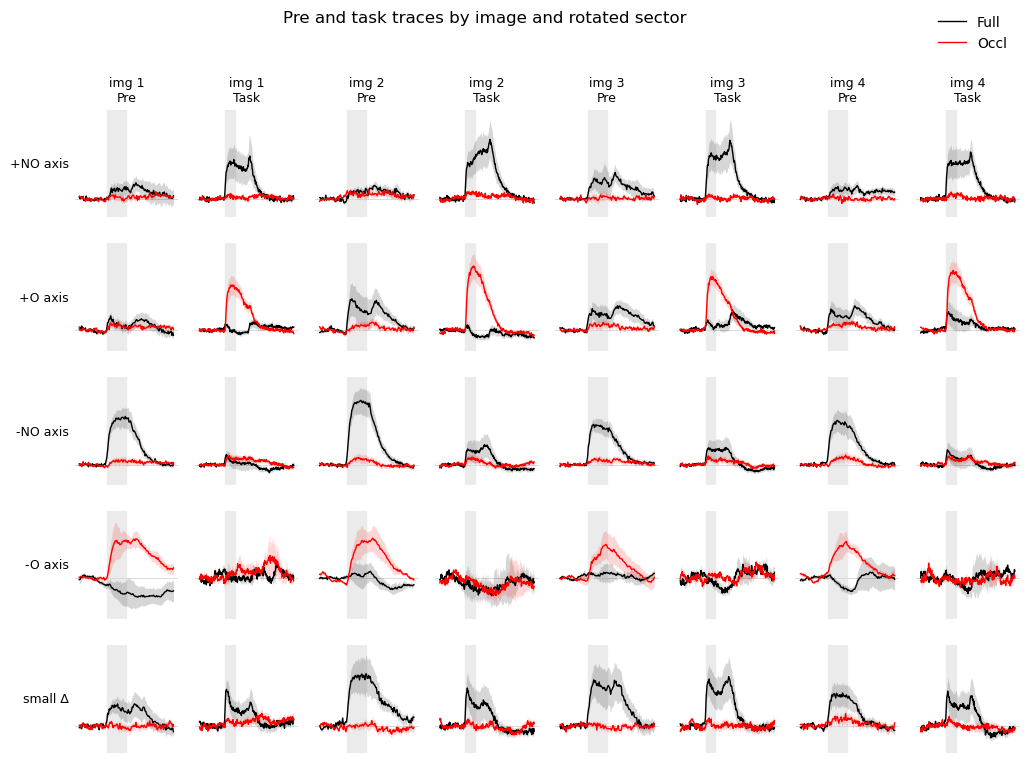

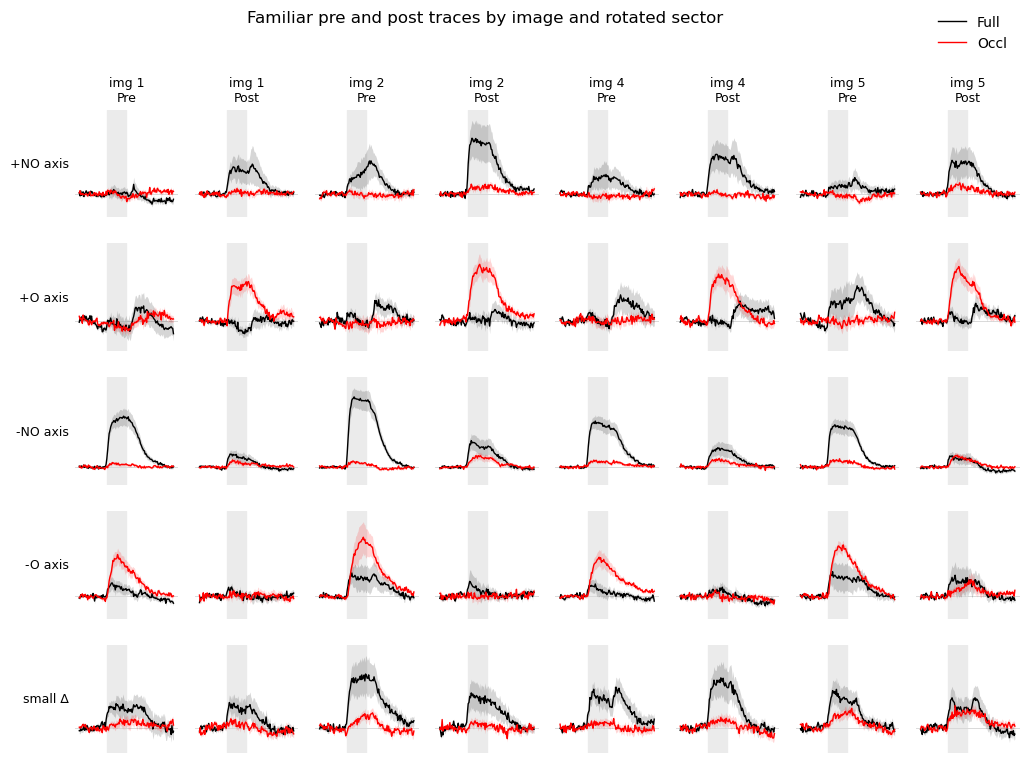

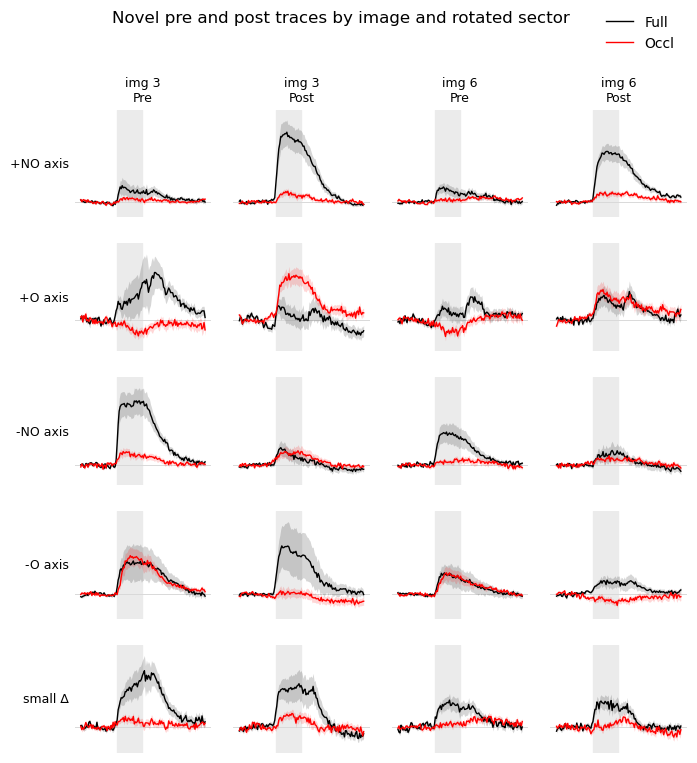

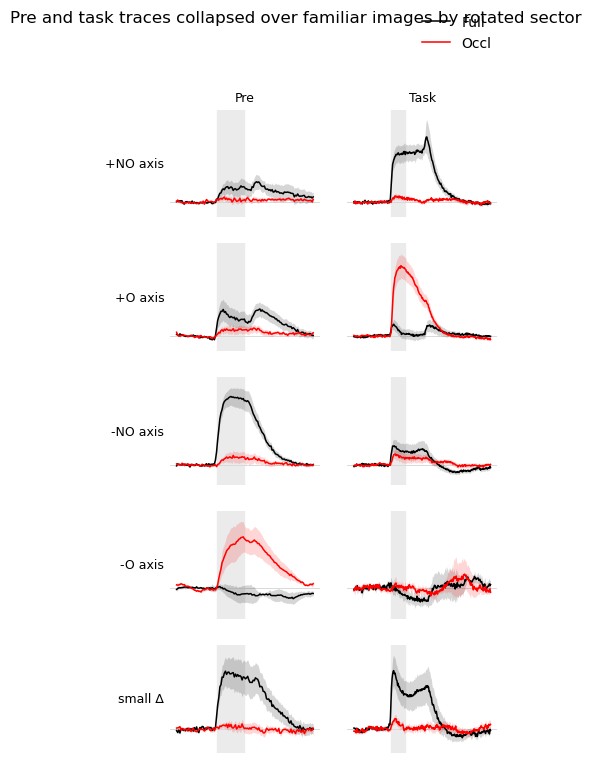

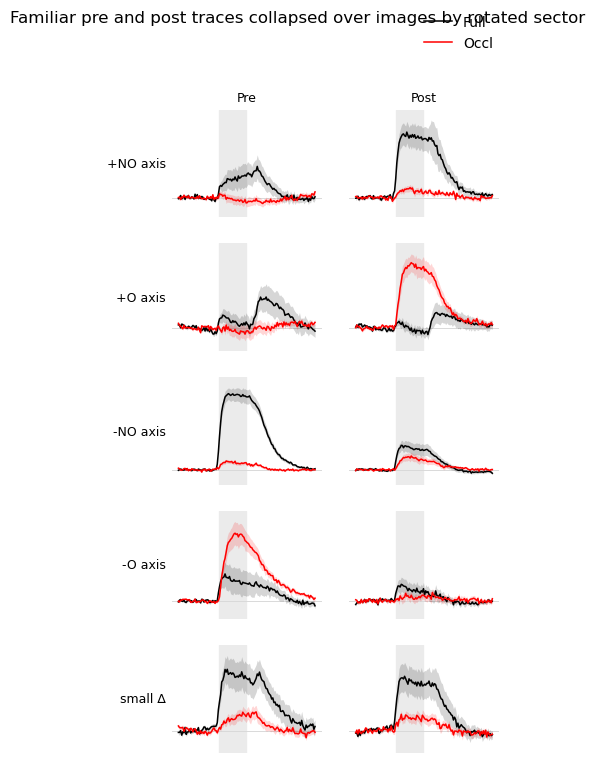

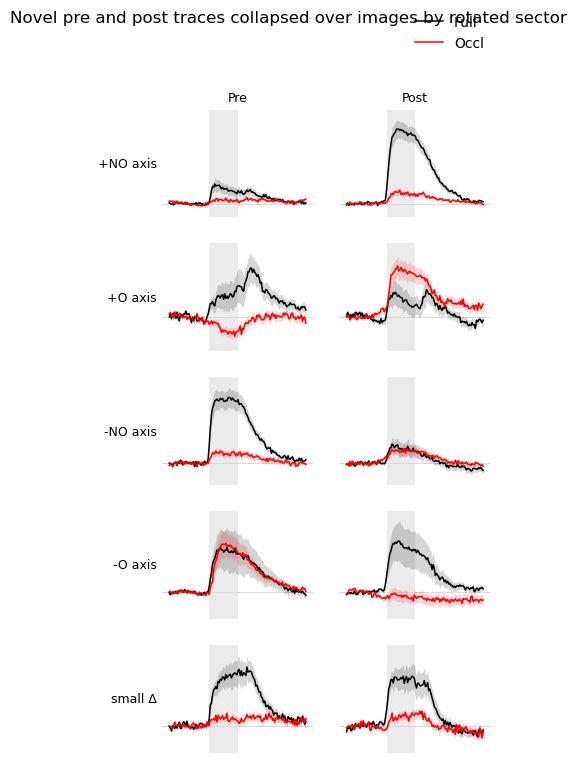

In [6]:
def _sem(values: pd.Series) -> float:
    valid = values.dropna()
    if len(valid) <= 1:
        return 0.0
    return float(valid.std(ddof=1) / np.sqrt(len(valid)))


def _ordered_sectors(frame: pd.DataFrame) -> list[str]:
    available = set(frame["RotatedSector"].astype(str))
    return [sector for sector in th.ROTATED_SECTOR_ORDER if sector in available]


def _style_trace_axis(ax: plt.Axes) -> None:
    ax.axhline(0.0, color="0.85", lw=0.7, zorder=0)
    ax.axvspan(0.2, 1.0, color="0.92", zorder=-1)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


def _apply_row_ylim(axes: np.ndarray, row_idx: int, row_bounds: list[float]) -> None:
    if not row_bounds:
        return
    lo = min(row_bounds)
    hi = max(row_bounds)
    pad = 0.12 * max(hi - lo, 0.2)
    for ax in axes[row_idx, :]:
        ax.set_ylim(lo - pad, hi + pad)


def _add_trace_legend(fig: plt.Figure, ax: plt.Axes) -> None:
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, frameon=False, loc="upper right", bbox_to_anchor=(0.995, 0.99))


def _image_stage_specs(frame: pd.DataFrame, *, image_group: str, stages: tuple[str, ...]) -> list[dict]:
    subset = frame.loc[frame["image_group"] == image_group]
    image_rows = (
        subset[["image_idx_original", "image_idx_within_group"]]
        .drop_duplicates()
        .sort_values(["image_idx_within_group", "image_idx_original"])
    )
    return [
        {
            "image_idx_original": int(row.image_idx_original),
            "image_idx_within_group": int(row.image_idx_within_group),
            "stage": stage,
            "label": f"img {int(row.image_idx_original)}\n{stage}",
        }
        for _, row in image_rows.iterrows()
        for stage in stages
    ]


def plot_sector_average_traces_by_image(
    frame: pd.DataFrame,
    *,
    image_group: str,
    stages: tuple[str, ...],
    title: str,
) -> plt.Figure:
    subset = frame.loc[frame["image_group"] == image_group].copy()
    specs = _image_stage_specs(subset, image_group=image_group, stages=stages)
    grouped = (
        subset.groupby(
            [
                "RotatedSector",
                "image_idx_original",
                "image_idx_within_group",
                "stage",
                "image_type",
                "time",
            ],
            observed=True,
        )
        .agg(
            response_mean=("response", "mean"),
            response_sem=("response", _sem),
            n_neurons=("neuron_idx", "nunique"),
        )
        .reset_index()
    )

    sectors = _ordered_sectors(grouped)
    fig, axes = plt.subplots(
        len(sectors),
        len(specs),
        figsize=(max(7.0, 1.35 * len(specs)), 1.45 * len(sectors) + 1.0),
        sharex=False,
        sharey="row",
        squeeze=False,
    )
    fig.subplots_adjust(left=0.12, right=0.995, top=0.86, bottom=0.08, wspace=0.16, hspace=0.24)

    for col_idx, spec in enumerate(specs):
        axes[0, col_idx].set_title(spec["label"], fontsize=9)

    for row_idx, sector in enumerate(sectors):
        row_bounds = []
        for col_idx, spec in enumerate(specs):
            ax = axes[row_idx, col_idx]
            panel = grouped.loc[
                (grouped["RotatedSector"].astype(str) == sector)
                & (grouped["image_idx_original"] == spec["image_idx_original"])
                & (grouped["image_idx_within_group"] == spec["image_idx_within_group"])
                & (grouped["stage"] == spec["stage"])
            ]
            for image_type, color in (("Full", "black"), ("Occl", "red")):
                trace_df = panel.loc[panel["image_type"] == image_type].sort_values("time")
                if trace_df.empty:
                    continue
                x = trace_df["time"].to_numpy(dtype=float)
                y = trace_df["response_mean"].to_numpy(dtype=float)
                sem = trace_df["response_sem"].fillna(0.0).to_numpy(dtype=float)
                ax.plot(x, y, color=color, lw=1.0, label=image_type)
                ax.fill_between(x, y - sem, y + sem, color=color, alpha=0.16, linewidth=0)
                row_bounds.extend([float(np.nanmin(y - sem)), float(np.nanmax(y + sem))])
            _style_trace_axis(ax)

        axes[row_idx, 0].set_ylabel(str(sector), rotation=0, ha="right", va="center", fontsize=9)
        _apply_row_ylim(axes, row_idx, row_bounds)

    _add_trace_legend(fig, axes[0, 0])
    fig.suptitle(title, y=0.98, fontsize=12)
    return fig


def plot_sector_average_traces_collapsed_images(
    frame: pd.DataFrame,
    *,
    image_group: str,
    stages: tuple[str, ...],
    title: str,
) -> plt.Figure:
    subset = frame.loc[frame["image_group"] == image_group].copy()
    per_neuron = (
        subset.groupby(["RotatedSector", "neuron_idx", "stage", "image_type", "time"], observed=True)
        .agg(response=("response", "mean"))
        .reset_index()
    )
    grouped = (
        per_neuron.groupby(["RotatedSector", "stage", "image_type", "time"], observed=True)
        .agg(
            response_mean=("response", "mean"),
            response_sem=("response", _sem),
            n_neurons=("neuron_idx", "nunique"),
        )
        .reset_index()
    )

    sectors = _ordered_sectors(grouped)
    fig, axes = plt.subplots(
        len(sectors),
        len(stages),
        figsize=(max(4.2, 1.8 * len(stages)), 1.45 * len(sectors) + 1.0),
        sharex=False,
        sharey="row",
        squeeze=False,
    )
    fig.subplots_adjust(left=0.2, right=0.98, top=0.86, bottom=0.08, wspace=0.18, hspace=0.24)

    for col_idx, stage in enumerate(stages):
        axes[0, col_idx].set_title(stage, fontsize=9)

    for row_idx, sector in enumerate(sectors):
        row_bounds = []
        for col_idx, stage in enumerate(stages):
            ax = axes[row_idx, col_idx]
            panel = grouped.loc[(grouped["RotatedSector"].astype(str) == sector) & (grouped["stage"] == stage)]
            for image_type, color in (("Full", "black"), ("Occl", "red")):
                trace_df = panel.loc[panel["image_type"] == image_type].sort_values("time")
                if trace_df.empty:
                    continue
                x = trace_df["time"].to_numpy(dtype=float)
                y = trace_df["response_mean"].to_numpy(dtype=float)
                sem = trace_df["response_sem"].fillna(0.0).to_numpy(dtype=float)
                ax.plot(x, y, color=color, lw=1.1, label=image_type)
                ax.fill_between(x, y - sem, y + sem, color=color, alpha=0.16, linewidth=0)
                row_bounds.extend([float(np.nanmin(y - sem)), float(np.nanmax(y + sem))])
            _style_trace_axis(ax)

        axes[row_idx, 0].set_ylabel(str(sector), rotation=0, ha="right", va="center", fontsize=9)
        _apply_row_ylim(axes, row_idx, row_bounds)

    _add_trace_legend(fig, axes[0, 0])
    fig.suptitle(title, y=0.98, fontsize=12)
    return fig


if sector_traces:
    fig_act_by_image = plot_sector_average_traces_by_image(
        sector_traces["act"],
        image_group="all",
        stages=("Pre", "Task"),
        title="Pre and task traces by image and rotated sector",
    )
    fig_post_familiar_by_image = plot_sector_average_traces_by_image(
        sector_traces["post"],
        image_group="familiar",
        stages=("Pre", "Post"),
        title="Familiar pre and post traces by image and rotated sector",
    )
    fig_post_novel_by_image = plot_sector_average_traces_by_image(
        sector_traces["post"],
        image_group="novel",
        stages=("Pre", "Post"),
        title="Novel pre and post traces by image and rotated sector",
    )

    fig_act_collapsed = plot_sector_average_traces_collapsed_images(
        sector_traces["act"],
        image_group="all",
        stages=("Pre", "Task"),
        title="Pre and task traces collapsed over familiar images by rotated sector",
    )
    fig_post_familiar_collapsed = plot_sector_average_traces_collapsed_images(
        sector_traces["post"],
        image_group="familiar",
        stages=("Pre", "Post"),
        title="Familiar pre and post traces collapsed over images by rotated sector",
    )
    fig_post_novel_collapsed = plot_sector_average_traces_collapsed_images(
        sector_traces["post"],
        image_group="novel",
        stages=("Pre", "Post"),
        title="Novel pre and post traces collapsed over images by rotated sector",
    )